# EDA - Analisis Exploratorio de Datos
Proyecto: Recomendador de Cultivos California (TFM)
Fuentes: CDL/USDA + PRISM (historico) + NASA NEX-GDDP-CMIP6 (futuro) + gSSURGO (suelo)

In [1]:
# imports librerias
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import os
import sys

# Buscamos la raíz del proyecto
current_dir = os.path.abspath(os.getcwd())
while current_dir != os.path.dirname(current_dir):
    if "main.py" in os.listdir(current_dir):
        break
    current_dir = os.path.dirname(current_dir)

# Registramos la raíz exacta en el sistema de Python
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

#Llamamos las configuraciones de mongo
from src.config import MONGO_URI, DB_NAME, COLLECTION_NAME
from src.utils import TARGET_CROPS


In [2]:
# ── Configuracion visual ────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 130
OUTPUT_DIR = "eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, bbox_inches="tight")
    print(f"  [guardado] {path}")
    plt.close(fig)

In [3]:
# Conexión a MongoDB
client = MongoClient(MONGO_URI)
db = client[DB_NAME]
collection = db[COLLECTION_NAME]

# traemos TODOS los documentos 
cursor = collection.find({}, {"_id": 0})
datos_lista = list(cursor)

df_raw = pl.DataFrame(datos_lista, infer_schema_length=None)

print(f"Dimensiones: {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas.")

Dimensiones: 1109452 filas, 41 columnas.


In [4]:
# Mostrar las primeras 5 filas de forma limpia
print("Primeras filas del dataset:")
display(df_raw.head())

Primeras filas del dataset:


year,crop_id,crop_name,is_target,location,processed,ppt,processed_climate,tmax,tmean,tmin,vpdmax,vpdmin,awc_r,cec7_r,claytotal_r,dbthirdbar_r,ec_r,ecec_r,ksat_r,om_r,pbray1_r,ph1to1h2o_r,processed_soil,profundidad_efectiva_cm,ptotal_r,sandtotal_r,silttotal_r,sumbases_r,es_proyeccion,hurs_245,hurs_585,pr_245,pr_585,referencia_base,tmax_245,tmax_585,tmean_245,tmean_585,tmin_245,tmin_585
i64,i64,str,bool,struct[2],bool,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,null,f64,f64,f64,bool,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64
2008,2,"""Cotton""",true,"{""Point"",[-120.703207, 37.125374]}",false,203.770004,true,23.848001,15.783001,7.719,22.509001,1.777,0.15,15.0,31.0,1.35,3.0,null,2.7,0.75,null,8.2,true,30.0,null,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null
2008,212,"""Oranges""",true,"{""Point"",[-119.113253, 35.622238]}",false,129.257004,true,24.682001,17.624001,10.568001,25.107,4.256,0.17,24.4,31.0,1.45,0.0,null,9.0,0.75,null,7.9,true,46.0,null,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null
2008,3,"""Rice""",true,"{""Point"",[-121.880199, 39.018031]}",false,370.766022,true,23.924002,16.358002,8.792001,23.787001,2.398,0.16,48.5,59.299999,1.18,0.9,null,0.42,3.99,null,6.8,true,9.0,null,0.9,39.799999,45.0,null,null,null,null,null,null,null,null,null,null,null,null
2008,75,"""Almonds""",true,"{""Point"",[-119.128831, 35.717057]}",false,131.94101,true,24.880001,17.76,10.641001,25.513,4.177,0.11,7.5,15.0,1.55,1.0,null,28.0,0.75,null,7.9,true,28.0,null,65.900002,19.1,null,null,null,null,null,null,null,null,null,null,null,null,null
2008,69,"""Grapes""",true,"{""Point"",[-120.119889, 37.04136]}",false,206.222015,true,24.250002,16.461,8.673,24.395,2.449,0.09,8.1,15.0,1.55,1.0,null,5.5,1.0,null,6.3,true,23.0,null,66.0,19.0,6.9,null,null,null,null,null,null,null,null,null,null,null,null


### Tipos de Datos

In [12]:
tabla_esquema = pl.DataFrame({
    "Columna": list(df_raw.schema.keys()),
    "Tipo de Dato": [str(dtype) for dtype in df_raw.schema.values()]
})

#visualizar
with pl.Config(tbl_rows=-1):
    display(tabla_esquema)

Columna,Tipo de Dato
str,str
"""year""","""Int64"""
"""crop_id""","""Int64"""
"""crop_name""","""String"""
"""is_target""","""Boolean"""
"""location""","""Struct({'type': String, 'coord…"
"""processed""","""Boolean"""
"""ppt""","""Float64"""
"""processed_climate""","""Boolean"""
"""tmax""","""Float64"""


### Análisis de Missing Values

In [5]:
# Calculamos el total de nulos por columna (mantiene los nombres originales de las variables)
total_nulos = df_raw.select(pl.all().null_count())

# Calculamos el porcentaje de nulos por columna
porcentaje_nulos = df_raw.select((pl.all().null_count() / pl.count() * 100).round(2))

# tabla nulos (Nombre | Total | %)
df_nulls = pl.DataFrame({
    "Variable": df_raw.columns,
    "Total Nulos": total_nulos.row(0),
    "% Nulos": porcentaje_nulos.row(0)
}).sort("Total Nulos", descending=True)

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(df_nulls)

C:\Users\lesli\AppData\Local\Temp\ipykernel_31584\3499373317.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  porcentaje_nulos = df_raw.select((pl.all().null_count() / pl.count() * 100).round(2))


Variable,Total Nulos,% Nulos
str,i64,f64
"""ptotal_r""",1109452,100.0
"""pbray1_r""",1109448,100.0
"""ecec_r""",1091224,98.36
"""es_proyeccion""",999452,90.09
"""hurs_245""",999452,90.09
"""hurs_585""",999452,90.09
"""pr_245""",999452,90.09
"""pr_585""",999452,90.09
"""referencia_base""",999452,90.09


**Tratamiento de Nulos**

In [22]:
# Eliminamos de golpe las variables que venían totalmente vacías desde la fuente
# # Creamos una copia de trabajo limpia
df_imputed = df_raw.clone()
df_imputed = df_imputed.drop(["ptotal_r", "pbray1_r"])

En la revisión de nulos se puede ver que el dataset original tiene 9.91% de nulos en las series climáticas base (`tmax`, `tmin`, `ppt`) y entre un 66% y 7% en las propiedades edáficas provenientes de gSSURGO. En lugar de optar por una eliminar las observaciones que tienen estos missing values, se imputarán los datos, así no se pierde información valiosa. En este caso la imputación debe hacerse con cuidado ya que estamos hablando de datos espaciales no podemos simplemente usar medias o promedios, por tanto se utilizará la Imputación por Vecindad Espacio-Temporal Condicionada (o Imputación por Rejilla Virtual) este esta basado en un KNN  pero condiciona a que los vecinos de encuentran asociados a la longitud y latidud a aproximadamente 11km de resolución para el mismo año que estamos evaluando. 

In [ ]:
# Imputación Geoespacial y Temporal 
# Creamos la rejilla espacial virtual usando redondeo de coordenadas
# Redondeamos a 1 decimal (~11 km de precisión) para definir la vecindad regional
df_imputed = df_imputed.with_columns([
    pl.col("location").struct.field("coordinates").list.get(0).round(1).alias("grid_lon"),
    pl.col("location").struct.field("coordinates").list.get(1).round(1).alias("grid_lat")
])

# IMPUTACIÓN CLIMÁTICA: Media por Rejilla Espacial y Año
variables_clima = ["tmax", "tmin", "ppt", "tmean"]

for var in variables_clima:
    if var in df_imputed.columns:
        df_imputed = df_imputed.with_columns(
            pl.col(var).fill_null(
                pl.col(var).mean().over(["grid_lon", "grid_lat", "year"])
            )
        )

# IMPUTACIÓN EDÁFICA (SUELO): Mediana por Rejilla Espacial
variables_suelo = [
    "cec7_r", "claytotal_r", "sandtotal_r", "silttotal_r", 
    "om_r", "awc_r", "ph1to1h2o_r", "ksat_r", "dbthirdbar_r", "ec_r", "profundidad_efectiva_cm"
]

for var in variables_suelo:
    if var in df_imputed.columns:
        df_imputed = df_imputed.with_columns(
            pl.col(var).fill_null(
                pl.col(var).median().over(["grid_lon", "grid_lat"])
            )
        )

# 5. CAPA DE SEGURIDAD GLOBAL (Cierre de nulos remotos)
# Si algún punto está tan aislado que no tiene vecinos en su cuadrícula, 
# se le asigna la mediana general histórica de todo California para esa variable.
for var in variables_clima + variables_suelo:
    if var in df_imputed.columns:
        df_imputed = df_imputed.with_columns(
            pl.col(var).fill_null(pl.col(var).median())
        )

# Eliminamos las columnas temporales de la rejilla para dejar el dataset limpio
df_imputed = df_imputed.drop(["grid_lon", "grid_lat"])


In [24]:
# 1. Definimos la lista de todas las variables analizadas
variables_analizadas = variables_clima + variables_suelo

# 2. Calculamos los nulos originales manteniendo el nombre de la variable y luego aplicando melt
nulos_antes = (
    df_raw.select([pl.col(v).null_count() for v in variables_analizadas])
    .melt(variable_name="Variable", value_name="Nulos Originales")
)

# 3. Calculamos los nulos finales de la misma manera
nulos_despues = (
    df_imputed.select([pl.col(v).null_count() for v in variables_analizadas])
    .melt(variable_name="Variable", value_name="Nulos Restantes")
)

# 4. Unimos ambos análisis por la columna 'Variable' y calculamos la diferencia exacta
auditoria_imputacion = (
    nulos_antes.join(nulos_despues, on="Variable", how="inner")
    .with_columns([
        (pl.col("Nulos Originales") - pl.col("Nulos Restantes")).alias("Total Imputados")
    ])
    .sort("Total Imputados", descending=True)
)

# Mostramos la tabla completa sin cortes en tu Jupyter
with pl.Config(tbl_rows=-1):
    display(auditoria_imputacion)

C:\Users\lesli\AppData\Local\Temp\ipykernel_31584\3632465117.py:7: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="Variable", value_name="Nulos Originales")
C:\Users\lesli\AppData\Local\Temp\ipykernel_31584\3632465117.py:13: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="Variable", value_name="Nulos Restantes")


Variable,Nulos Originales,Nulos Restantes,Total Imputados
str,u32,u32,u32
"""tmax""",110000,0,110000
"""tmin""",110000,0,110000
"""ppt""",110000,0,110000
"""tmean""",110000,0,110000
"""cec7_r""",83296,0,83296
"""silttotal_r""",80607,0,80607
"""sandtotal_r""",80578,0,80578
"""claytotal_r""",79820,0,79820
"""ph1to1h2o_r""",78645,0,78645


### Qué cultivos tenemos dentro del dataset?

In [25]:
#Distribución de observaciones por Tipo de Cultivo
# Agrupar por cultivo y contar
crop_counts = (
    df_imputed.group_by(["crop_id", "crop_name"])
    .agg(pl.count().alias("Muestras"))
    .sort("Muestras", descending=True)
)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(crop_counts)



C:\Users\lesli\AppData\Local\Temp\ipykernel_31584\1275664361.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("Muestras"))


crop_id,crop_name,Muestras
i64,str,u32
75,"""Almonds""",153512
36,"""Alfalfa""",152531
61,"""Fallow/ Idle Cropland""",148870
69,"""Grapes""",93617
3,"""Rice""",57631
37,"""Other Hay/Non Alfalfa""",55237
24,"""Winter Wheat""",53330
76,"""Walnuts""",47375
204,"""Pistachios""",46255


**Homologar cultivos de Lechuga**

Existen datos de parcelas que tienen cultivos de lechuga con otros cultivos, dado que nuestro cultivo de interes es lechuga y en estas tierras se encuentra sembrada lechuga renombraremos estos cultivos como "Lettuce" y el codigo como "227"

In [ ]:
#Homologar cultivos de lechuga
# Aplicamos la lógica de homologación usando pl.when().then().otherwise()
df_imputed = df_imputed.with_columns([
    # 1. Homologación de CROP_ID
    pl.when(pl.col("crop_id").is_in([231, 233])).then(227)
        .otherwise(pl.col("crop_id"))
    .alias("crop_id"),

    # 2. Homologación de CROP_NAME
    pl.when(pl.col("crop_id").is_in([231, 233])).then(pl.lit("Lettuce"))
    .otherwise(pl.col("crop_name"))
    .alias("crop_name")
])

### Creación dataset con cultivos priorizados

In [ ]:
#  Extraemos las llaves (IDs de los cultivos) para usarlas como filtro
target_crop_ids = list(TARGET_CROPS.keys()) + [24, 22, 36]

#Filtramos el DataFrame usando la eficiencia de Polars
# El método .is_in() busca si el 'crop_id' de la fila pertenece a nuestra lista
df2 = df_imputed.filter(pl.col("crop_id").is_in(target_crop_ids))

print(f"Dimensiones originales: {df_imputed.shape[0]} filas, {df_imputed.shape[1]} columnas.")
print(f"Dimensiones del dataset filtrado: {df2.shape[0]} filas, {df2.shape[1]} columnas.")

Dimensiones originales: 1109452 filas, 41 columnas.
Dimensiones del dataset filtrado: 687136 filas, 41 columnas.


In [19]:
# Validamos qué cultivos quedaron y cuántas muestras tiene cada uno
check_cultivos = (
    df2.group_by(["crop_id", "crop_name"])
    .agg(pl.count().alias("Total Muestras"))
    .sort("Total Muestras", descending=True)
)

with pl.Config(tbl_rows=-1):
    display(check_cultivos)

C:\Users\lesli\AppData\Local\Temp\ipykernel_31584\699851678.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("Total Muestras"))


crop_id,crop_name,Total Muestras
i64,str,u32
75,"""Almonds""",153512
36,"""Alfalfa""",152531
69,"""Grapes""",93617
3,"""Rice""",57631
24,"""Winter Wheat""",53330
76,"""Walnuts""",47375
204,"""Pistachios""",46255
54,"""Tomatoes""",28897
2,"""Cotton""",27591


In [28]:
#Análisis de Missing values

# Calculamos el total de nulos por columna (mantiene los nombres originales de las variables)
total_nulos = df2.select(pl.all().null_count())

# Calculamos el porcentaje de nulos por columna
porcentaje_nulos = df2.select((pl.all().null_count() / pl.count() * 100).round(2))

# tabla nulos (Nombre | Total | %)
df2_nulls = pl.DataFrame({
    "Variable": df2.columns,
    "Total Nulos": total_nulos.row(0),
    "% Nulos": porcentaje_nulos.row(0)
}).sort("Total Nulos", descending=True)

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(df2_nulls)

C:\Users\lesli\AppData\Local\Temp\ipykernel_31584\4236345251.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  porcentaje_nulos = df2.select((pl.all().null_count() / pl.count() * 100).round(2))


Variable,Total Nulos,% Nulos
str,i64,f64
"""ptotal_r""",687136,100.0
"""pbray1_r""",687135,100.0
"""ecec_r""",678251,98.71
"""es_proyeccion""",621840,90.5
"""hurs_245""",621840,90.5
"""hurs_585""",621840,90.5
"""pr_245""",621840,90.5
"""pr_585""",621840,90.5
"""referencia_base""",621840,90.5


### Cantidad de observaciones por año

C:\Users\lesli\AppData\Local\Temp\ipykernel_31584\3507409690.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("Muestras"))


year,Muestras
i64,u32
2008,34366
2009,33685
2010,35224
2011,33090
2012,34643
2013,34030
2014,33894
2015,33490
2016,34715


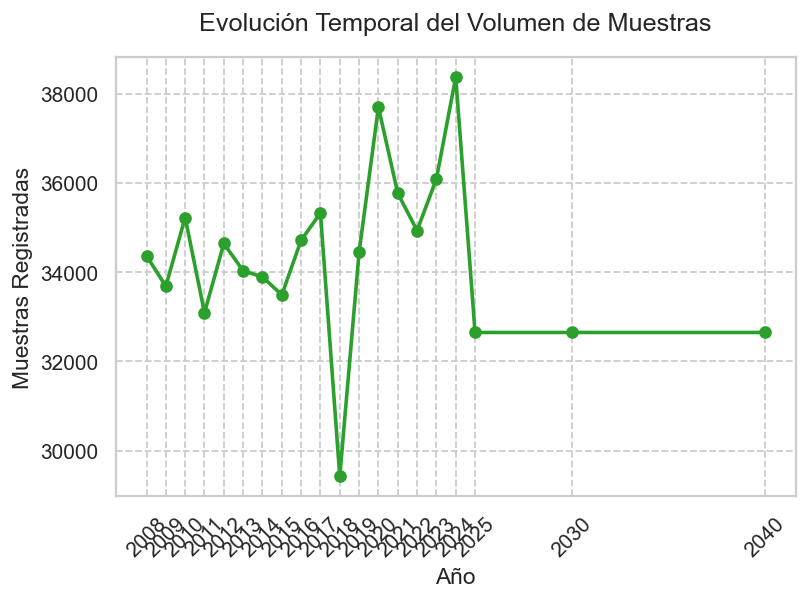

In [27]:
#Distribución de observaciones por Año

year_counts = (
    df2.group_by("year")
    .agg(pl.count().alias("Muestras"))
    .sort("year")
)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(year_counts)

# Gráfico de línea temporal
plt.plot(year_counts["year"], year_counts["Muestras"], marker='o', color='#2ca02c', linewidth=2)
plt.title("Evolución Temporal del Volumen de Muestras", fontsize=14, pad=15)
plt.xlabel("Año")
plt.ylabel("Muestras Registradas")
plt.xticks(year_counts["year"], rotation=45)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [31]:
# Resumen Estadístico de las Propiedades Edáficas:

# Seleccionamos las variables numéricas clave de suelos
soil_cols = [
    "claytotal_r", "sandtotal_r", "silttotal_r", 
    "om_r", "ph1to1h2o_r", "awc_r", "profundidad_efectiva_cm"
]

# Filtramos solo las columnas que existan en tu DF y calculamos el resumen
existing_soil_cols = [col for col in soil_cols if col in df2.columns]
display(df2.select(existing_soil_cols).describe())

statistic,claytotal_r,sandtotal_r,silttotal_r,om_r,ph1to1h2o_r,awc_r,profundidad_efectiva_cm
str,f64,f64,f64,f64,f64,f64,f64
"""count""",687136.0,687136.0,687136.0,687136.0,687136.0,687136.0,687136.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",25.175032,42.591461,32.061894,1.741025,7.356365,0.140442,29.338827
"""std""",15.37453,23.819398,13.804733,3.428795,0.814752,0.040609,18.40128
"""min""",0.0,0.0,0.0,0.0,4.0,0.0,1.0
"""25%""",13.0,22.1,19.6,0.75,6.7,0.12,16.0
"""50%""",21.0,39.799999,31.700001,1.25,7.5,0.14,25.0
"""75%""",33.0,67.199997,40.0,2.0,8.0,0.16,38.0
"""max""",70.0,98.900002,85.699997,100.0,9.8,0.6,203.0


C:\Users\lesli\AppData\Local\Temp\ipykernel_31584\3777658780.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


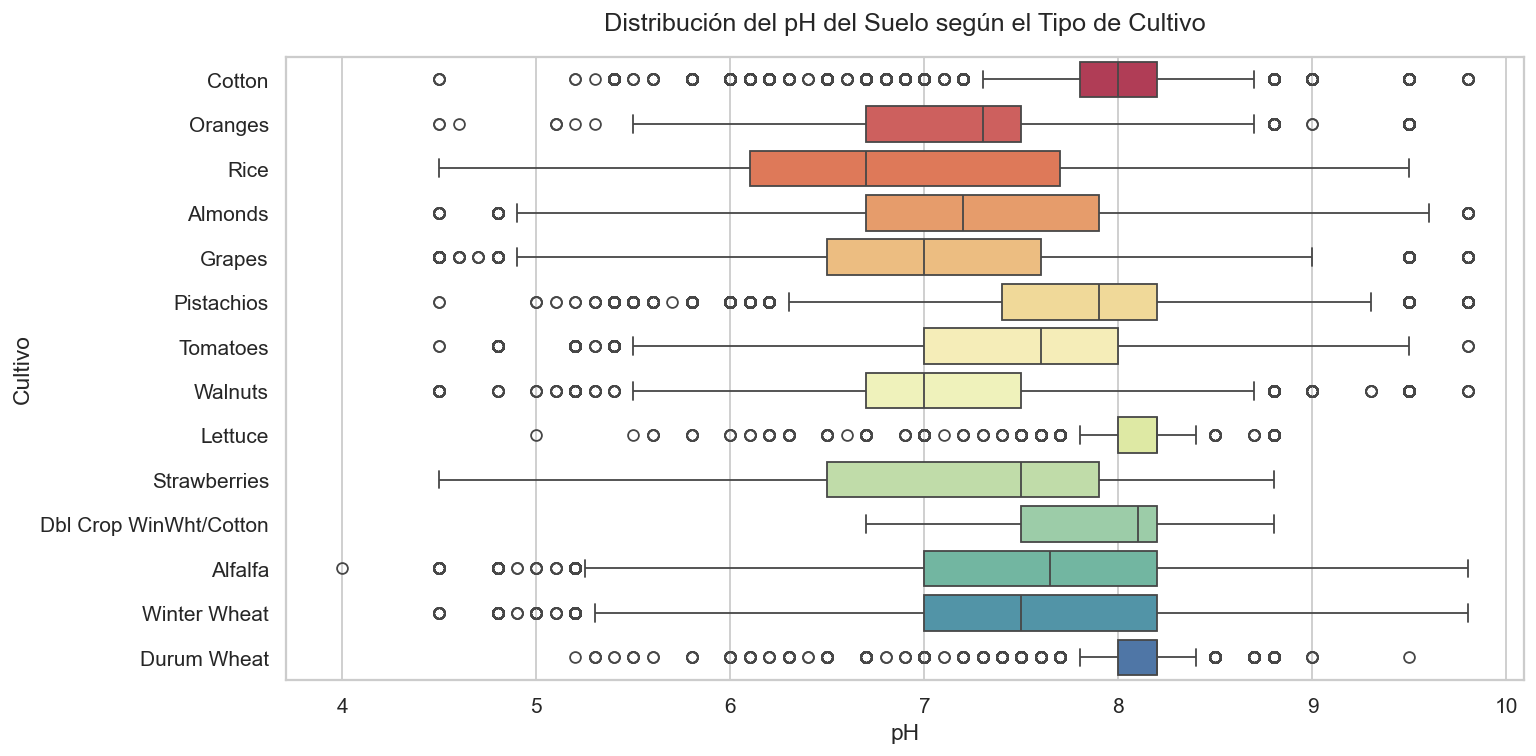

In [32]:
if "ph1to1h2o_r" in df2.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df2.select(["crop_name", "ph1to1h2o_r"]).to_pandas(),
        x="ph1to1h2o_r",
        y="crop_name",
        palette="Spectral"
    )
    plt.title("Distribución del pH del Suelo según el Tipo de Cultivo", fontsize=14, pad=15)
    plt.xlabel("pH")
    plt.ylabel("Cultivo")
    plt.tight_layout()
    plt.show()